# Density Estimation

In [ ]:
%pip install git+https://github.com/DMJTax/prtools.git

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import prtools as pr

# Parzen Density Estimation

Parzen density estimation is a non-parametric method for estimating the probability density function of a random variable. It uses kernel functions (often Gaussian) centered at each data point to build up the density estimate.

**Main formula:**
$$
\hat{p}(x) = \frac{1}{n h^d} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
$$
Where:
- $n$: number of data points
- $h$: kernel width (bandwidth)
- $d$: dimensionality of the data
- $K$: kernel function (e.g., Gaussian)
- $x_i$: data points

**Type:** Non-parametric, generative, density estimator

**Ideal use case:**
- When you want to estimate the underlying probability density of data without assuming a parametric form
- Flexible for multimodal and complex distributions

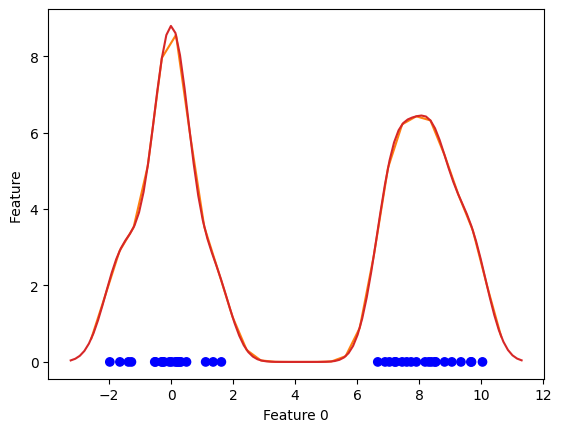

In [3]:
#We start with creating a simple dataset with:
a = pr.gendats([20,20],1,8)

#We define the width parameter h for the Parzen kernel:
h = 0.5

#The function parzenm estimates a density for a given dataset. In most cases a PRTools prdataset is labeled, and these labels are used in the function parzenm to estimate a density for each class. To define a Parzen density estimator with a certain width parameter h on the entire dataset, ignoring labels, type:
a = pr.prdataset(+a)
w = pr.parzenm(a,h)

#This mapping can now be plotted along with the data:
pr.scatterd(a)
pr.plotm(w)

#If your graphs look a little “bumpy”, you can increase the grid size PRTools uses for plotting:

pr.plotm(w,gridsize=100)

When you want to evaluate the fit of a density model to some data, you have to define an error. One possibility is to use the log-likelihood, defined as:

$$
LL(X) = \log \prod_i \hat{p}(x_i) = \sum_i \log(\hat{p}(x_i)) \tag{1.2}
$$

The better the data $x$ fits in the probability density model $\hat{p}$, the higher the values of $\hat{p}(x)$ will be. This will result in a high value of $\sum_i \log(\hat{p}(x_i))$. When we have different probability density estimates $\hat{p}$, we use the one which has the highest value of $LL$.

Note that when we fill in different values for the width parameters $h$ in the Parzen density estimation, we have different estimates $\hat{p}$. Using the log-likelihood as a criterion, we can optimize the value of this free parameter $h$ to maximize $LL$.

To get an honest estimate of the log-likelihood, we have to evaluate the log-likelihood (1.2) on a test set. That means that we have to make (or measure) new data from the same distribution as where the training data came from.